# Ridge Regression problem on Diamonds dataset - Analyzing convergence results.

# Introduction

The primary objective of this study is to conduct a comparative analysis of the convergence behavior of various optimization algorithms applied on a Ridge Regression problem to the Diamonds Dataset.

In particular, the focus is on 
* Evaluating the respective algorithms convergence rates.
* Investigating how theoretical properties of the objective function (such as Smoothness and Strongly Convexity) have an impact to the results.
* Evaluating how the $L_2$ regularization parameter ($\lambda$) of Ridge Regression influences speed and efficiency of the algorithms.

The following algorithms were implemented:
* Gradient Descent (Naive, Bounded, Smooth)
* Accelerated Gradient Descent (Nesterov's)
* Stochastic Gradient Descent (Naive, Strongly Convex)
* Newton's Method

# Dataset Overview: The Diamonds Dataset

To evaluate the performance of the optimization algorithms, we utilized the **Diamonds Dataset**. The dataset consists of approximately **54,000 observations** ($n=53,940$), each representing a diamond with **10 distinct attributes**.

The primary objective is to predict with a Ridge Regression the **Price** of a diamond based on its physical and quality characteristics.

### Feature Description
The variables can be categorized into numerical (continuous) and categorical (ordinal) features:

* **Target Variable ($y$):**
    * `price`: Price in US dollars (ranging from \$326 to \$18,823).

* **Numerical Features:**
    * `carat`: Weight of the diamond (0.2 - 5.01). This is the most significant predictor of price.
    * `x`: Length in mm.
    * `y`: Width in mm.
    * `z`: Depth in mm.
    * `depth`: Total depth percentage ($z / \text{mean}(x, y)$).
    * `table`: Width of the top of the diamond relative to the widest point.

* **Categorical Features (Ordinal):**
    * `cut`: Quality of the cut (Fair, Good, Very Good, Premium, Ideal).
    * `color`: Diamond color, from J (worst) to D (best).
    * `clarity`: A measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best)).

**Multicollinearity:**
The dataset exhibits high correlation between features, particularly between `carat` and the dimensions (`x`, `y`, `z`). This structural redundancy results in a data matrix $X$ with a very small minimum eigenvalue ($\lambda_{\min} \approx 0$), making the optimization problem **ill-conditioned** and particularly challenging for standard gradient-based methods.

# Mathematical Analysis: Ridge Regression

In this study, we address the **Ridge Regression** problem, which extends Ordinary Least Squares (OLS) by imposing an $L_2$ penalty on the model parameters to mitigate overfitting and multicollinearity.

### 1. The Objective Function

The objective function is the sum of squared errors for each data point ($i=1$ to $n$) plus the sum of squared weights (from $j=1$ to $d$).

$$f(w) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - x_i^T w)^2 + \frac{\lambda}{2} \sum_{j=1}^{d} w_j^2$$

The objective function $f(w)$ is defined in vector notation as follows.

$$
f(w) = \underbrace{\frac{1}{2n} \| Xw - y \|_2^2}_{\text{Loss}} + \underbrace{\frac{\lambda}{2} \| w \|_2^2}_{\text{Regularization}}
$$

Where:
* $X \in \mathbb{R}^{n \times d}$ is the feature matrix (standardized, includes a column of 1 ).
* $y \in \mathbb{R}^n$ is the target vector.
* $w \in \mathbb{R}^d$ is the vector of weights to be optimized.
* $\lambda > 0$ is the regularization hyperparameter.

#### Why the scaling?
Introducing specific scaling factors is convenient for mathematical and numerical stability:
* **The factor $\frac{1}{2}$**: Cancels out the exponent $2$ when computing the gradient $\nabla f(w)$ and the derivative of $\|w\|^2$, simplifying to a linear form without constant multipliers.
* **The factor $\frac{1}{n}$**: Normalizes the error term with respect to the dataset size. This ensures that the magnitude of the loss (and consequently the gradient) is independent of the number of samples $n$. This allows the same learning rates to be effective regardless of whether we use the full dataset or a smaller subset.

### 2. Gradient and Hessian Matrix 
Since $f(w)$ is differentiable, we can work with first-order derivative (the Gradient) and second-order derivative (the Hessian matrix) to minimize the objective function.

#### 2.1. The Gradient $\nabla f(w)$
The gradient represents the direction of the steepest ascent of the function. 
To find the minimum, optimization algorithms like Gradient Descent move in the opposite direction of the gradient. 
Let's expand the vector notation of the objective function:
$$
f(w) = {\frac{1}{2n} \| Xw - y \|_2^2} + {\frac{\lambda}{2} \| w \|_2^2}
$$

$$f(w) = \frac{1}{2n} (Xw - y)^T (Xw - y) + \frac{\lambda}{2} w^T w$$

Let's expand the error quadratic term:
$$
\begin{aligned}
(y - Xw)^T (y - Xw) &= (y^T - (Xw)^T)(y - Xw) \\
&= (y^T - w^T X^T)(y - Xw) \\
&= y^T y - y^T X w - w^T X^T y + w^T X^T X w
\end{aligned}
$$

The terms $y^T X w$ and $w^T X^T y$ are scalars (yielding a $1 \times 1$ result). 
In linear algebra, the transpose of a scalar is the scalar itself. 
So $(y^T X w)^T = w^T X^T y$. 
Therefore, these two terms are identical and can be combined:
$$- y^T X w - w^T X^T y = -2 w^T X^T y$$

Now we substitute all in the original function:
$$
f(w) = \frac{1}{2n} \left( y^T y - 2 w^T X^T y + w^T X^T X w \right) + \frac{\lambda}{2} w^T w
$$

The gradient is the vector of partial derivatives with respect to $w$. 
To compute the gradients and Hessians, we rely on the following standard matrix calculus properties (assuming $w$ and $b$ are column vectors, and $A$ is a symmetric matrix):

1. **Constant rule:** $\nabla_w (b) = 0$ 
2. **Linear form:** $\nabla_w (w^T b) = \nabla_w (b^T w) = b$
3. **Jacobian of a linear mapping:** $\nabla_w (A w) = A$ 
4. **Quadratic form:** $\nabla_w (w^T A w) = 2Aw$ *(Requires $A$ to be symmetric, i.e., $A = A^T$. In our case, $X^T X$ and $I$ are both symmetric).*

Let's apply these rules to each term of $f(w)$:

1. **Term $y^T y$**: Does not depend on $w$.
   $$\nabla_w (\dots) = 0$$

2. **Term $-2 w^T (X^T y)$**: Here $b = X^T y$.
   $$\nabla_w \left( \frac{1}{2n} (-2 w^T X^T y) \right) = -\frac{1}{n} \nabla_w (w^T (X^T y)) = -\frac{1}{n} X^T y$$

3. **Term $w^T (X^T X) w$**: Here $A = X^T X$. Note that $X^T X$ is symmetric.
   $$\nabla_w \left( \frac{1}{2n} w^T X^T X w \right) = \frac{1}{2n} (2 X^T X w) = \frac{1}{n} X^T X w$$

4. **Regularization term: $\frac{\lambda}{2} w^T w$**: Here $A = I$ (identity matrix).
   $$\nabla_w \left( \frac{\lambda}{2} w^T I w \right) = \frac{\lambda}{2} (2 I w) = \lambda w$$

**Gradient Result:**
Summing all the parts together:
$$
\nabla f(w) = \frac{1}{n} (X^T X w - X^T y) + \lambda w
$$
Factoring out common terms, this is also frequently written as:
$$\nabla f(w) = \frac{1}{n} X^T (Xw - y) + \lambda w$$

---

#### 2.2. The Hessian Matrix $\nabla^2 f(w)$
The Hessian matrix is the derivative of the gradient with respect to $w$ (i.e., the second derivative of the original function). It is a $d \times d$ matrix.

Let's recall the expression for the gradient:
$$\nabla f(w) = \frac{1}{n} X^T X w - \frac{1}{n} X^T y + \lambda w$$

We differentiate each term with respect to $w$. We use the matrix calculus identity $\nabla_w (Aw) = A$:

1.  **Term $\frac{1}{n} X^T X w$**:
    The constant matrix multiplying $w$ is $\frac{1}{n} X^T X$.
    $$\nabla^2 (\dots) = \frac{1}{n} X^T X$$

2.  **Term $-\frac{1}{n} X^T y$**:
    This term does not contain $w$ (it is a constant vector).
    $$\nabla^2 (\dots) = 0$$

3.  **Term $\lambda w$**:
    We can rewrite this as $\lambda I w$. The constant matrix is $\lambda I$.
    $$\nabla^2 (\dots) = \lambda I$$

**Hessian Result:**
$$
H = \nabla^2 f(w) = \frac{1}{n} X^T X + \lambda I
$$

### 3. $f(w)$ is strictly convex
To understand the convexity of our objective function, we rely on the formal definition of definite matrices based on their quadratic forms: *A symmetric matrix $M$ is Positive Semi-Definite if $v^T M v \ge 0$ for all vectors $v$, and Positive Definite if $v^T M v > 0$ for all non-zero vectors $v \neq 0$.*

Let's apply this definition to our Ridge Regression Hessian matrix, $H = \frac{1}{n} X^T X + \lambda I$, by analyzing its quadratic form $v^T H v$ for any arbitrary non-zero vector $v \in \mathbb{R}^d$:

$$v^T H v = v^T \left( \frac{1}{n} X^T X + \lambda I \right) v$$

By distributing the multiplication, we get:

$$v^T H v = \frac{1}{n} v^T X^T X v + \lambda v^T I v$$

We can rewrite the first term using the property of transposes, $(Xv)^T = v^T X^T$, and the second term using the definition of the squared $L_2$ norm, $v^T v = \|v\|_2^2$:

$$v^T H v = \frac{1}{n} (Xv)^T (Xv) + \lambda \|v\|_2^2$$

$$v^T H v = \underbrace{\frac{1}{n} \|Xv\|_2^2}_{\text{OLS Base}} + \underbrace{\lambda \|v\|_2^2}_{\text{Ridge Penalty}}$$

Now, let's evaluate the two components:

* **The OLS Base:** The squared norm $\|Xv\|_2^2$ is a squared length, meaning it is always non-negative ($\ge 0$). This proves that the unregularized Hessian ($\frac{1}{n} X^T X$) is intrinsically **Positive Semi-Definite**. However, if features are perfectly collinear, there exist non-zero vectors $v$ where $Xv = 0$. In these cases, the quadratic form equals zero, meaning the loss landscape has flat valleys with no unique minimum.
* **The Ridge Penalty:** For any non-zero vector $v \neq 0$, its squared norm $\|v\|_2^2$ is strictly positive. Since our regularization hyperparameter is strictly positive ($\lambda > 0$), the entire term $\lambda \|v\|_2^2$ must be strictly greater than zero ($> 0$).

Because we are adding a strictly positive term ($\lambda \|v\|_2^2 > 0$) to a non-negative term ($\frac{1}{n} \|Xv\|_2^2 \ge 0$), the entire sum is guaranteed to be strictly positive:

$$v^T H v > 0 \quad \text{for all } v \neq 0$$

By the mathematical definition, this proves that the Ridge Hessian matrix $H$ is **Positive Definite**. The $L_2$ penalty mathematically eliminates any flat regions, guaranteeing that the objective function possesses a single, unique global minimum, so that means $f(w)$ is strictly convex.



# Ridge Regression - Properties

To understand how iterative optimization algorithms will behave on Ridge Regression objective function $f(w)$, we must analyze its properties. 

#### 1. Convexity: Yes (Strictly Convex)
As proven in the previous section using the Hessian's quadratic form, the addition of the $L_2$ penalty ensures that the Hessian matrix $H$ is Positive Definite. Therefore, the function is not just convex, but **strictly convex**. This guarantees that any local minimum is the unique global minimum $w^*$.

#### 2. Lipschitz Continuous: No (Globally)
A function $f(w)$ is globally $B$-Lipschitz if its gradients are bounded in magnitude everywhere ($\| \nabla f(w) \| \le B$). 
Our objective function $f(w)$ is a quadratic function. As the weights $w$ grow toward infinity, the gradient $\nabla f(w) = \frac{1}{n} X^T (Xw - y) + \lambda w$ also grows linearly toward infinity. Because the gradient is unbounded over the entire domain $\mathbb{R}^d$, the function itself is **not globally Lipschitz continuous**.

#### 3. Smoothness ($L$-smooth): Yes
It is **$L$-Smooth**.
The curvature does not change abruptly; the gradient doesn't oscillate wildly. The function always lies *below* a certain parabola: 

$$f(y) \le f(x) + \nabla f(w)^T (y - x) + \frac{L}{2} \|x - y\|^2$$

* **Value of $L$:** It corresponds to the largest eigenvalue of the Hessian matrix (the maximum curvature of the loss landscape).
  $$L = \lambda_{\max}\left(\frac{1}{n}X^T X\right) + \lambda$$
* **Consequence:** This value acts as the absolute **speed limit** for Gradient Descent. The optimal safe step size is typically $\gamma = \frac{1}{L}$.


#### 4. Strong Convexity ($\mu$-strongly convex): Yes
It is **$\mu$-Strongly Convex**.
The curvature is "at least" $\mu$ in every direction. The function always lies *above* the quadratic function:

$$f(y) \ge f(x) + \nabla f(x)^T (y - w) + \frac{\mu}{2} \|x - y\|^2$$

* **Value of $\mu$:** It corresponds to the smallest eigenvalue of the Hessian matrix.
  $$\mu = \lambda_{\min}\left(\frac{1}{n}X^T X\right) + \lambda$$
  *(Note: If the matrix $X$ is not full-rank, the first term is $0$, meaning $\mu = \lambda$. This mathematically proves that without regularization ($\lambda=0$), the problem might not be strongly convex, which would make convergence much slower).*
* **Consequence:** It guarantees **Linear** (fast) convergence for Gradient Descent. The larger $\mu$ is, the faster the algorithm will converge to the minimum.






# The expected effect of L2 regularization on convergence

![grafico](images/normal-parabola-ridge.png)

### The Effect of $\lambda$ on the Cost Function

We expect that the regularization parameter $\lambda$ has an geometric impact on the shape of our cost function. 

By increasing the value of $\lambda$, the parabola will visibly "narrows" and becomes significantly steeper. Mathematically, we are adding a quadratic penalty $\frac{\lambda}{2} \|w\|^2$ to the original loss, which dominates the overall curvature. This visual narrowing is the exact graphical representation of the increase in the strong convexity parameter $\mu$ (the quadratic *lower bound*) that we discussed previously.

**Expected Results on Convergence:**
Because the "walls" of our cost function become much steeper, the gradients (i.e., the slopes the algorithm calculates at each step) will be much more pronounced. Consequently, we expect that as $\lambda$ increases, the Gradient Descent algorithm will be pushed toward the global minimum much more rapidly and decisively, requiring a significantly lower number of iterations to reach the convergence criterion.

# Import and Preparing Dataset

To prepare the dataset for our optimization algorithms, we now apply the following preprocessing steps:

1. **Ordinal Encoding:** Categorical variables (`cut`, `color`, `clarity`) were mapped to integer values, preserving their inherent hierarchy. This safely converts text labels into a numerical format that the mathematical model can process.
2. **Removing Outliers:** We filter out extreme anomalous data points. Since our objective function relies on Mean Squared Error (MSE), it is highly sensitive to outliers, which could disproportionately skew the optimization of our weights.
3. **Plot data:** We generate visual distributions to understand the underlying shape, scale, and potential skewness of our features before feeding them into the model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [2]:


df = pd.read_csv('diamonds.csv', index_col=0) #Oss: Column 0 is carat

df.rename(columns={'depth': 'depth_p'}, inplace=True)
df.rename(columns={'table': 'table_p'}, inplace=True)

#Initial shuffle - stochastic algorithm rely on before each epoch
df = df.sample(frac=1).reset_index(drop=True)

#Ordinal Encoding
cut_mapping = {
    'Fair': 1, 
    'Good': 2, 
    'Very Good': 3, 
    'Premium': 4, 
    'Ideal': 5
}

# 'color' map (Color: J=1, D=7)
# D is the best, J the worse.
color_mapping = {
    'J': 1, 
    'I': 2, 
    'H': 3, 
    'G': 4, 
    'F': 5, 
    'E': 6, 
    'D': 7
}

# Clarity map (Clarity: I1=1, IF=8)
# IF is the best (Internally Flawless), I1 the worse.
clarity_mapping = {
    'I1': 1, 
    'SI2': 2, 
    'SI1': 3, 
    'VS2': 4, 
    'VS1': 5, 
    'VVS2': 6, 
    'VVS1': 7, 
    'IF': 8
}

df['cut'] = df['cut'].map(cut_mapping)
df['color'] = df['color'].map(color_mapping)
df['clarity'] = df['clarity'].map(clarity_mapping)

#### To check NaN
print(df.isna().sum())



carat      0
cut        0
color      0
clarity    0
depth_p    0
table_p    0
price      0
x          0
y          0
z          0
dtype: int64


In [3]:
# Removing Outliers
def detect_outlier(x):
    """
    Return a boolean mask (Series):
    True if the value is an outlier, False otherwise.
    """
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (IQR * 1.5)
    upper_bound = Q3 + (IQR * 1.5)
    
    return (x > upper_bound) | (x < lower_bound)

def remove_outlier(df, columns=None):
    """
    Remove rows that cointains outliers
    """
    if columns is None:
        columns = df.columns

    df_cleaned = df.copy()

    for col in columns:
        # Find outlier in the corrent column
        outliers_mask = detect_outlier(df_cleaned[col])
        
        # Filtering: remains only rows that aren't outliers
        df_cleaned = df_cleaned[~outliers_mask]
        
    print("Outliers removed")
    df_cleaned = df_cleaned.reset_index(drop=True)
    print(f"New dimension: {df_cleaned.shape}")
    return df_cleaned

#Removing outliers for numerical features
cols_to_check = ['carat', 'depth_p', 'table_p', 'price', 'x', 'y', 'z']
df = remove_outlier(df, cols_to_check)

print(df)


Outliers removed
New dimension: (46532, 10)
       carat  cut  color  clarity  depth_p  table_p  price     x     y     z
0       0.34    5      5        8     60.7     57.0   1074  4.50  4.53  2.74
1       0.71    2      3        6     60.4     63.0   2738  5.69  5.74  3.45
2       0.51    3      1        3     62.6     59.0    930  5.06  5.10  3.18
3       1.01    5      4        4     59.6     59.0   6295  6.52  6.57  3.90
4       0.91    3      7        3     63.1     59.0   4586  6.14  6.10  3.86
...      ...  ...    ...      ...      ...      ...    ...   ...   ...   ...
46527   1.09    3      3        3     63.2     57.0   4871  6.57  6.54  4.14
46528   0.62    3      7        5     63.4     55.0   2310  5.46  5.43  3.45
46529   0.72    5      6        4     60.6     57.0   3145  5.85  5.83  3.54
46530   0.90    2      6        2     61.6     61.0   3595  6.12  6.16  3.78
46531   0.36    5      7        3     62.7     57.0    663  4.54  4.59  2.86

[46532 rows x 10 columns]


## Visualize Data

Now we use the `matplotlib` library to generate a visual dashboard that explores the distribution of all the main variables within the diamonds dataset. 

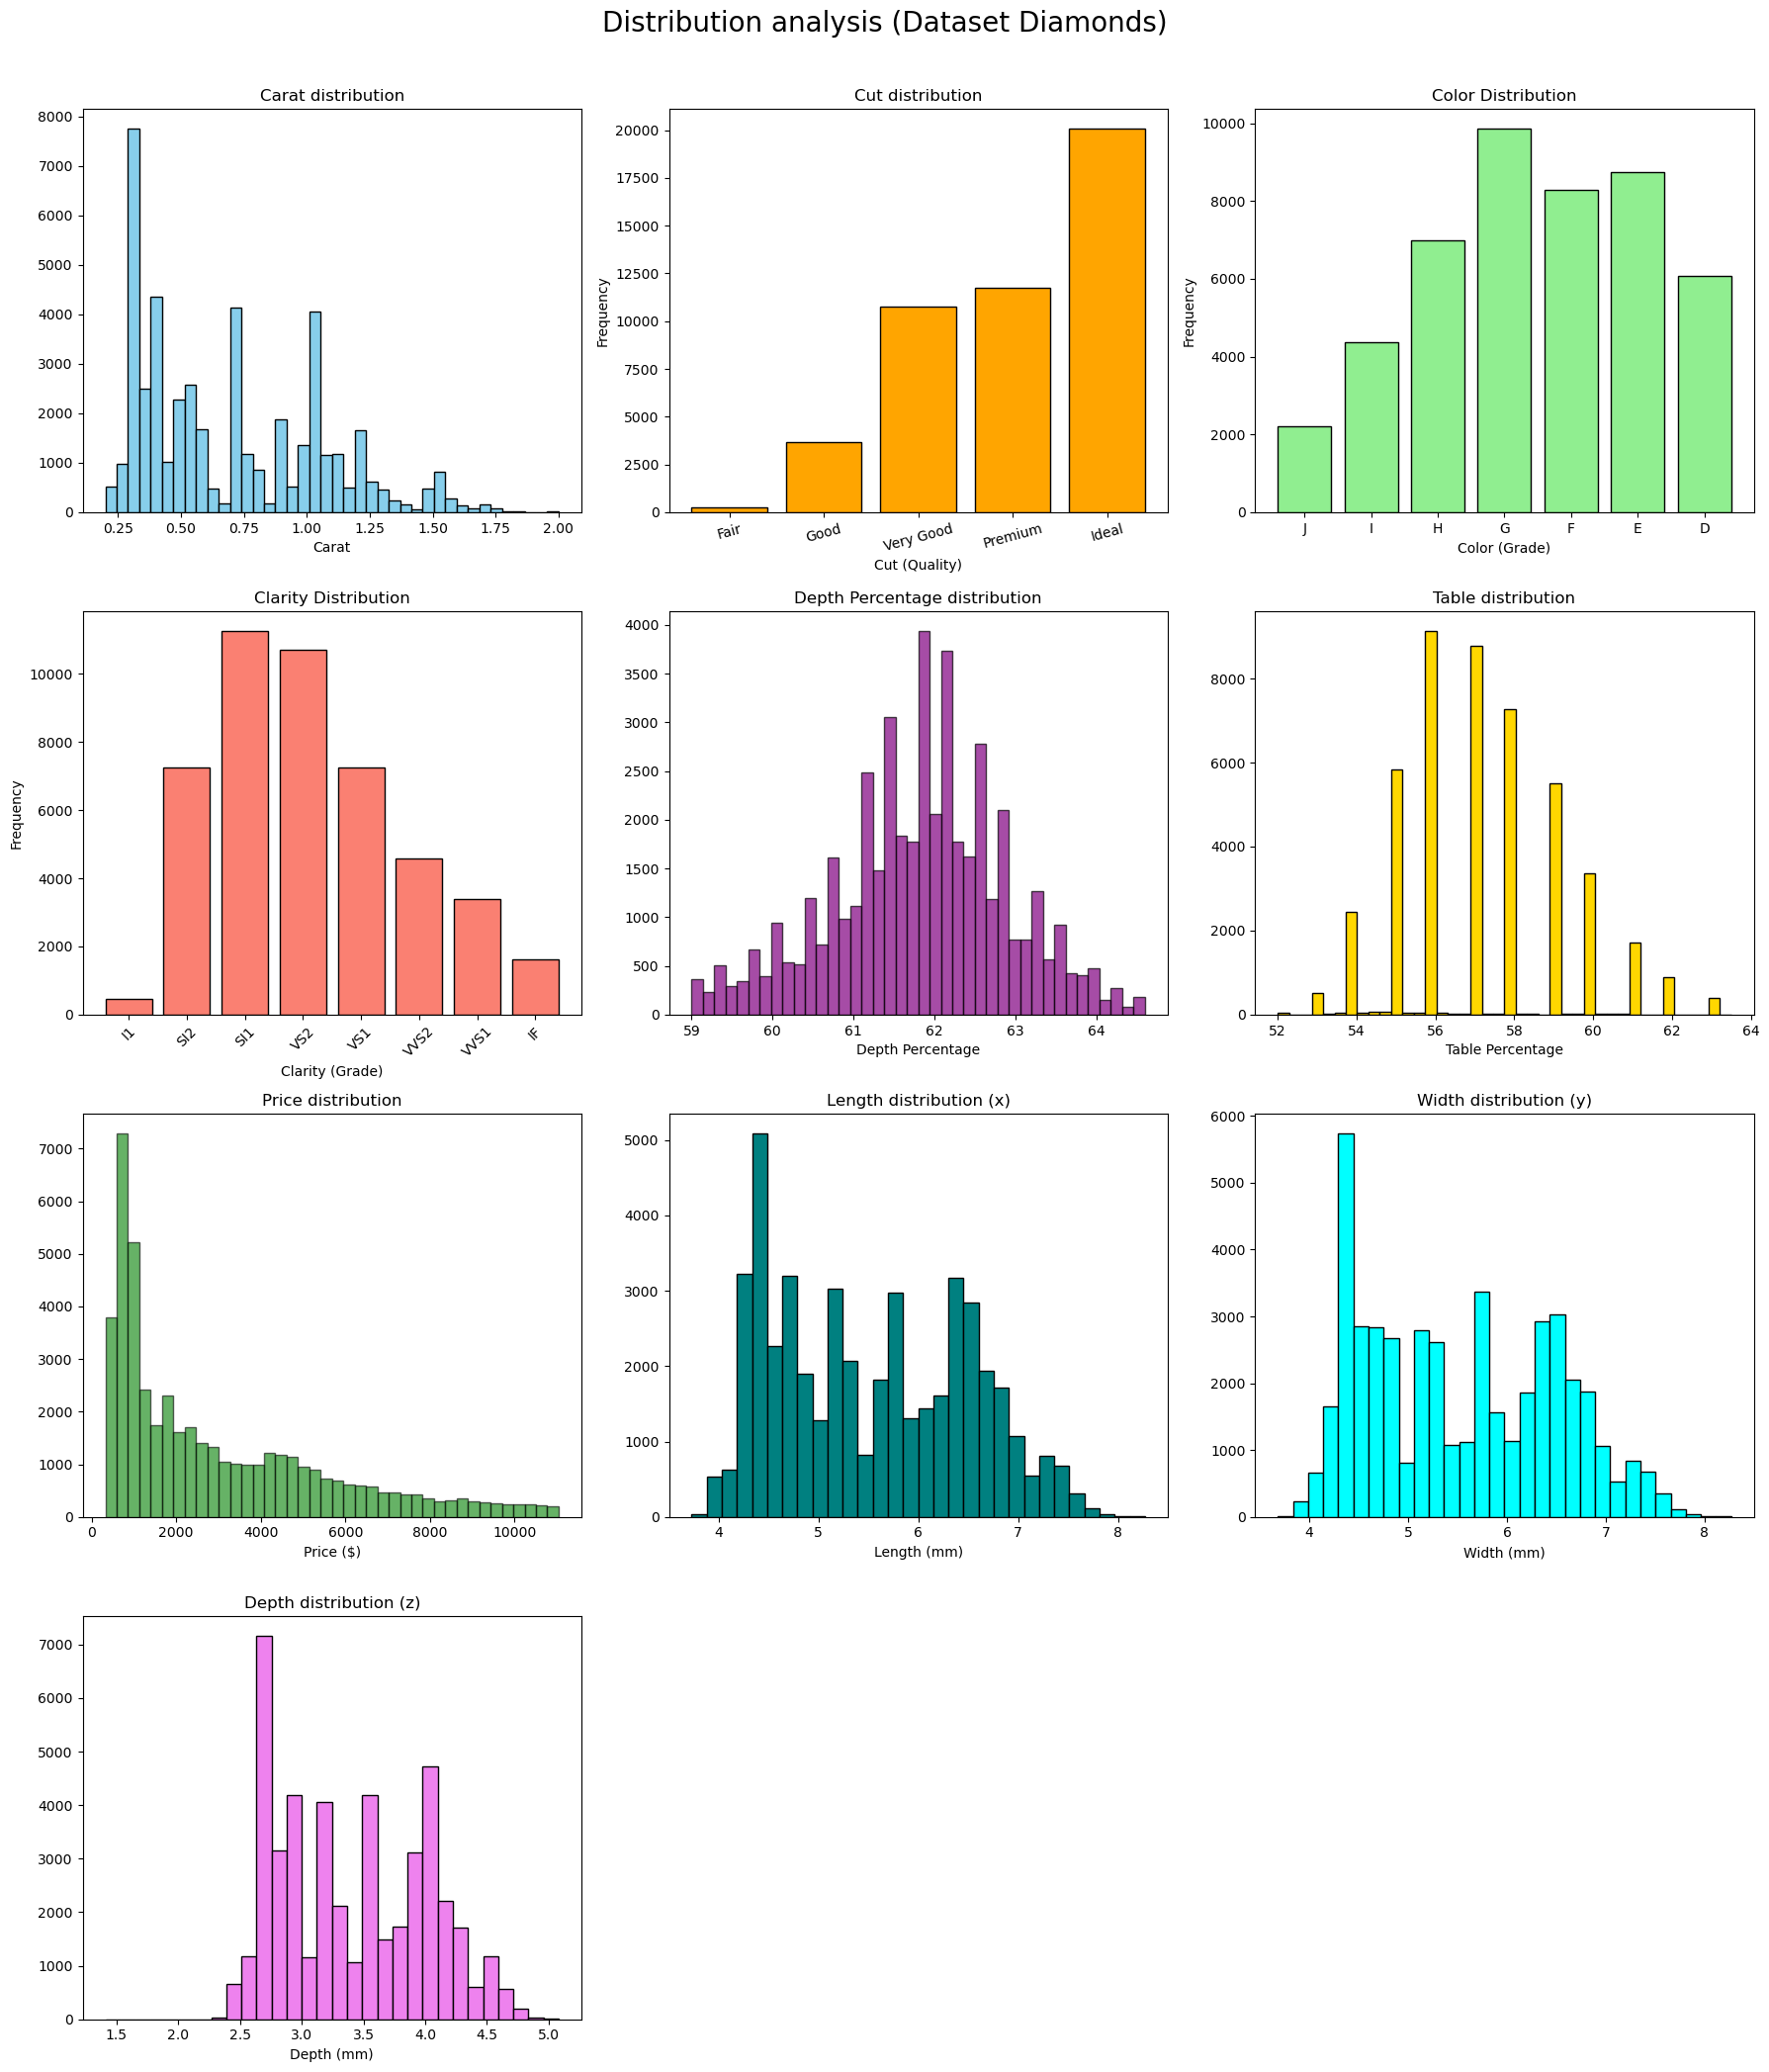

In [4]:

cut_labels = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_labels = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_labels = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']


fig, axes = plt.subplots(4, 3, figsize=(18, 22)) # Aumentato leggermente l'altezza
fig.suptitle('Distribution analysis (Dataset Diamonds)', fontsize=20)
ax = axes.flatten()

# --- 1. Carat ---
ax[0].hist(df['carat'], bins=40, color='skyblue', edgecolor='black')
ax[0].set_title('Carat distribution')
ax[0].set_xlabel('Carat')

# --- 2. Cut ---
cut_counts = df['cut'].value_counts().sort_index()
ax[1].bar(cut_counts.index, cut_counts.values, color='orange', edgecolor='black')
ax[1].set_title('Cut distribution')
ax[1].set_xlabel('Cut (Quality)')
ax[1].set_ylabel('Frequency')
# Sostituzione numeri con nomi
ax[1].set_xticks(cut_counts.index) # Posiziona i tick sui numeri (1,2,3,4,5)
ax[1].set_xticklabels(cut_labels, rotation=15) # Sostituisce con le stringhe

# --- 3. Color  ---
color_counts = df['color'].value_counts().sort_index()
ax[2].bar(color_counts.index, color_counts.values, color='lightgreen', edgecolor='black')
ax[2].set_title('Color Distribution')
ax[2].set_xlabel('Color (Grade)')
ax[2].set_ylabel('Frequency')
# Sostituzione numeri con nomi
ax[2].set_xticks(color_counts.index)
ax[2].set_xticklabels(color_labels)

# --- 4. Clarity ---
clarity_counts = df['clarity'].value_counts().sort_index()
ax[3].bar(clarity_counts.index, clarity_counts.values, color='salmon', edgecolor='black')
ax[3].set_title('Clarity Distribution')
ax[3].set_xlabel('Clarity (Grade)')
ax[3].set_ylabel('Frequency')
# Sostituzione numeri con nomi
ax[3].set_xticks(clarity_counts.index)
ax[3].set_xticklabels(clarity_labels, rotation=45) # Ruotiamo perché sono tanti

# --- 5. Depth Percentage ---
ax[4].hist(df['depth_p'], bins=40, color='purple', alpha=0.7, edgecolor='black')
ax[4].set_title('Depth Percentage distribution')
ax[4].set_xlabel('Depth Percentage')

# --- 6. Table Percentage ---
ax[5].hist(df['table_p'], bins=40, color='gold', edgecolor='black')
ax[5].set_title('Table distribution')
ax[5].set_xlabel('Table Percentage')

# --- 7. Price ---
ax[6].hist(df['price'], bins=40, color='green', alpha=0.6, edgecolor='black')
ax[6].set_title('Price distribution')
ax[6].set_xlabel('Price ($)')

# --- 8. Length (x) ---
ax[7].hist(df['x'], bins=30, color='teal', edgecolor='black')
ax[7].set_title('Length distribution (x)')
ax[7].set_xlabel('Length (mm)')

# --- 9. Width (y) ---
ax[8].hist(df['y'], bins=30, color='cyan', edgecolor='black')
ax[8].set_title('Width distribution (y)')
ax[8].set_xlabel('Width (mm)')

# --- 10. Depth mm (z) ---
ax[9].hist(df['z'], bins=30, color='violet', edgecolor='black')
ax[9].set_title('Depth distribution (z)')
ax[9].set_xlabel('Depth (mm)')

# --- Clean ---
ax[10].axis('off')
ax[11].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) 
plt.show()

## Mean and Standard Deviation Analysis

Let's now examine the mean and standard deviation across all features in our dataset. Since these features exist on vastly different scales, **standardizing the data** will be a crucial preprocessing step. This ensures that the Gradient Descent algorithm converges efficiently, stably, and without being unfairly dominated by features with naturally larger magnitudes.

In [5]:

print(df.describe().T)

           count         mean          std     min     25%      50%      75%  \
carat    46532.0     0.697966     0.362025    0.20    0.37     0.59     1.01   
cut      46532.0     4.025724     1.014818    1.00    3.00     4.00     5.00   
color    46532.0     4.464820     1.685251    1.00    3.00     4.00     6.00   
clarity  46532.0     4.126773     1.643282    1.00    3.00     4.00     5.00   
depth_p  46532.0    61.804302     1.077341   59.00   61.20    61.90    62.50   
table_p  46532.0    57.238621     2.013841   52.00   56.00    57.00    59.00   
price    46532.0  2999.000107  2598.654394  326.00  880.00  2002.50  4523.00   
x        46532.0     5.521339     0.964476    3.73    4.62     5.39     6.39   
y        46532.0     5.526371     0.958648    3.68    4.63     5.40     6.39   
z        46532.0     3.413855     0.597215    1.41    2.85     3.33     3.96   

              max  
carat        2.00  
cut          5.00  
color        7.00  
clarity      8.00  
depth_p     64.60  

## Data Preprocessing and Standardization

Before feeding our data into the optimization algorithm, we must carefully preprocess our matrices. The code block above performs several critical steps to ensure numerical stability and algorithmic efficiency:

1. **Standardizing the Features ($X$):** By subtracting the mean and dividing by the standard deviation, we ensure all features share the same scale (a mean of 0 and a variance of 1). This is crucial because it prevents features with naturally larger ranges from dominating the cost function. Geometrically, it transforms the loss landscape from an elongated ellipse into a much more spherical shape, which allows Gradient Descent to converge significantly faster.
2. **Standardizing the Target ($y$):** Standardizing the target variable greatly improves numerical stability. It keeps the computed gradients within a reasonable, bounded scale and ensures that initializing our weight vector to zero is a solid and mathematically logical starting point.
3. **The Bias Trick (Adding a column of 1s):** We append a column composed entirely of ones to our feature matrix $X$. This elegant mathematical trick allows us to absorb the intercept (or bias) term directly into our weight vector $w$.
4. **Reshaping for Matrix Algebra:** In NumPy, a flat 1D array with shape `(n,)` behaves differently than a strict 2D column vector with shape `(n, 1)`. We explicitly reshape our $y$ vector and weight initializations to ensure they are true column vectors. This guarantees code's linear algebra operations (like transposes and dot products) execute exactly as written in theoretical formulas.

In [6]:
from sklearn.preprocessing import StandardScaler

def standardize(x):
  """Standardize vector 1-D"""
  mean_val = np.mean(x)
  std_val = np.std(x)
  x_scaled = (x - mean_val) / std_val
  return x_scaled

def build_model_data(regr, obj):
  """Creating data in Matrix Form"""
  num_samples = len(obj)
    
  # Add 1 column (Bias)
  X = np.c_[np.ones(num_samples), regr]
    
  # Transform y from (n,) to (n, 1)
  y = obj.reshape(-1, 1)
    
  return X, y


# Data extraction
features = df.drop('price', axis=1).values
price = df['price'].values

# Features standardization (X) with Sklearn
scaler = StandardScaler()
feat_scal = scaler.fit_transform(features)

# Standardize price (y)
price_scal = standardize(price)

# Build features matrix and objective value y
X, y = build_model_data(feat_scal, price_scal)

# Verifica Dimensioni
print(f"X shape: {X.shape}")  # (N, 10)
print(f"y shape: {y.shape}")  # (N, 1)



X shape: (46532, 10)
y shape: (46532, 1)


# Loss Value and Gradient functions

### Implementing the Objective Function and Gradient

Now we translate our mathematical formulas into functions using the NumPy library:

* **`compute_loss_value`**: This function calculates the total cost $f(w)$. It computes the regularized Mean Squared Error by summing the squared residuals (scaled by $1 / 2n$) and adding the $L_2$ penalty term.
* **`compute_gradient`**: This function evaluates the first-order derivative $\nabla f(w)$ using the exact analytical equation we derived earlier.

In [7]:

def compute_loss_value(Xwmy,w,lambda_i,n):
  "Calculate loss value for the objective function: 1/2n * ||Xw - y||^2 + lambda/2 * ||w||^2"
  value = 1 / (2*n) * (Xwmy**2).sum() + (lambda_i / 2) * (w**2).sum()
  return value


def compute_gradient(X,w,Xwmy,lambda_i,n):
  """Compute the gradient function."""
  grad = (1/n) * X.T.dot(Xwmy) + lambda_i * w
  return grad

## Computing the Exact Analytical Solution

We compute the exact global minimum $w^*$ and its corresponding optimal loss $f(w^*)$ across a predefined set of regularization hyperparameters (`lambda_set`). By knowing the absolute mathematical minimum beforehand, we can later evaluate exactly how well and how fast our iterative algorithms converge to the true solution.

To find this baseline, we directly apply the **closed-form solution** we derived in the mathematical analysis section using `np.linalg.solve(A, b)` which efficiently and stably solves the underlying linear system of equations $$\left( \frac{1}{n} X^T X + \lambda I \right) w = \frac{1}{n} X^T y$$ providing us with a highly accurate optimal weight vector `w_star`.


In [8]:
lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]

loss_values = []

n = X.shape[0]
d = X.shape[1]

for lambda_ in lambda_set:
  w_star = np.linalg.solve((1/n) * np.dot(X.T,X) + np.eye(d,d)* lambda_ , (1/n) * np.dot(X.T,y))
  Xwmy = X.dot(w_star) - y
  loss_value = compute_loss_value(Xwmy,w_star,lambda_,n)
  
  loss_value = round(loss_value,8)
  loss_values.append(loss_value)


print(loss_values)

[0.04265771, 0.04276069, 0.04369175, 0.04977553, 0.07101217, 0.16355421]


### Why Training Error Increases with $\lambda$

As the regularization hyperparameter $\lambda$ increases, the training error (loss) inherently increases as well. This happens because the optimization algorithm is no longer solely focused on minimizing the residual errors to fit the training data perfectly. 
Instead, it must balance that goal with keeping the model weights ($w$) as small as possible to minimize the heavy $L_2$ penalty. By forcing the weights to shrink, we restrict the model's flexibility, preventing it from capturing every minor fluctuation and noise in the training set. 


# Gradient Descent

### Implementing Gradient Descent with Early Stopping

Now we implement the core iterative optimization algorithm: **Gradient Descent**. 

This function updates our weight vector $w$ step-by-step by moving in the opposite direction of the gradient, scaled by the learning rate (step size) $\gamma$:
$$w^{(t+1)} = w^{(t)} - \gamma \nabla f(w^{(t)})$$

We have introduce a **stopping criterion**. Rather than blindly running for `max_iters`, the algorithm continuously monitors $\epsilon$ (epsilon): the absolute difference between the current loss and the exact analytical minimum (`opt_value`) we established in the previous step. 

If this difference drops below a microscopic tolerance threshold (`tol = 1e-6`), the algorithm recognizes that it has practically reached the global minimum and triggers an "early stop". It also records the history of the weights and loss values at each step.

In [9]:

def gradient_descent(X,y,initial_w,lambda_i,gamma,max_iters,opt_value,tol=1e-6):
  """Gradient descent - stops when epsilon < 1e-6 """
  
  n = X.shape[0]

  #Define vectors to store weights and loss function values
  ws = []
  loss_values = []

  w = initial_w.copy()
  
  for n_iter in range(max_iters + 1):

    Xwmy = X.dot(w) - y 

    #Computing loss value(to minimize) and epsilon
    value = compute_loss_value(Xwmy,w,lambda_i,n)
    epsilon = abs(value - opt_value)

    #store w and loss function value
    ws.append(w)
    loss_values.append(value)

    if epsilon < tol:
      print(f"For lambda = {lambda_i}: convergence reached at iteration {n_iter}")
      break

    # update w by a gradient descent step
    if(n_iter < max_iters):
      grad = compute_gradient(X,w,Xwmy,lambda_i,n)
      w = w - gamma * grad

  return loss_values,ws,n_iter
  


## Naive GD

### Running Gradient Descent with a Naive Learning Rate

Now we execute our Gradient Descent algorithm across our predefined set of $\lambda$ values. 

For this first run, we are intentionally using a **naive, very small learning rate**.

Choosing a tiny step size is a conservative and highly stable approach: it guarantees that our algorithm will not overshoot the minimum or diverge. However, this safety comes with a heavy trade-off in efficiency. Taking such microscopic steps means the algorithm might require a massive number of iterations to finally reach the bottom of the convex bowl, which is why we must allow a high computational budget (`max_iters = 50000`).

The code loops through each regularization strength, times the execution to measure computational efficiency, and stores all the final metrics—including the optimized weights, final loss, iterations needed to trigger the early stop, and elapsed time—into a structured `results_matrix` for further analysis.

In [10]:

# Setup
lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]
opt_loss_values = loss_values.copy()
gamma = 1e-4 #Small Naive gamma
max_iters = 50000

initial_w = np.zeros((X.shape[1], 1))

results_list = []

for lambda_, opt_value in zip(lambda_set, opt_loss_values):

  start_time = datetime.datetime.now()
  lv_nGD, ws_nGD,iter = gradient_descent(X, y, initial_w, lambda_, gamma,max_iters,opt_value)
  end_time = datetime.datetime.now()

  execution_time = (end_time - start_time).total_seconds()
    
  # Extracting the last iteration (the best)
  best_loss = lv_nGD[-1]
  best_w = ws_nGD[-1].flatten()
    
  # [lambda, loss, w0, w1, ..., wd, gamma, n_iter]
  row = np.r_[lambda_, best_loss, best_w,gamma,iter,execution_time]
    
  results_list.append(row)


results_matrix = np.array(results_list)



For lambda = 1.0: convergence reached at iteration 31209


In [11]:
# Results visualization
col_names = ['Lambda', 'Loss'] + [f'w{i}' for i in range(initial_w.shape[0])] + ['gamma'] +['Iterations'] + ["Time[s]"]
df_results = pd.DataFrame(results_matrix, columns=col_names)

print("\n--- Final results per Lambda ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_results.round(5)) 



--- Final results per Lambda ---
    Lambda     Loss   w0       w1       w2       w3       w4       w5       w6       w7       w8       w9   gamma  Iterations   Time[s]
0  0.00001  0.05510 -0.0  0.34994  0.01921  0.11553  0.22546  0.00414 -0.00030  0.22697  0.23034  0.22434  0.0001     50000.0  11.45883
1  0.00010  0.05512 -0.0  0.34991  0.01920  0.11551  0.22543  0.00413 -0.00030  0.22697  0.23033  0.22434  0.0001     50000.0  10.41231
2  0.00100  0.05528 -0.0  0.34960  0.01919  0.11530  0.22509  0.00412 -0.00029  0.22694  0.23029  0.22431  0.0001     50000.0  10.20867
3  0.01000  0.05689 -0.0  0.34654  0.01905  0.11326  0.22177  0.00394 -0.00017  0.22660  0.22990  0.22401  0.0001     50000.0   9.91509
4  0.10000  0.07171 -0.0  0.31962  0.01763  0.09516  0.19200  0.00246  0.00103  0.22289  0.22570  0.22062  0.0001     50000.0   9.29349
5  1.00000  0.16356 -0.0  0.20568  0.00692  0.02047  0.06179 -0.00115  0.00867  0.18263  0.18364  0.18148  0.0001     31209.0   7.10924



Analyzing the final execution table reveals two crucial behaviors of Ridge Regression driven by the regularization hyperparameter $\lambda$:

**Faster Convergence due to a Steeper Landscape:** 

As $\lambda$ increases (particularly visible at $\lambda = 1.0$), the algorithm requires significantly fewer iterations to converge, dropping from the maximum $50,000$ down to $31,209$.
If the features are correlated (and in our diamonds dataset, they are highly correlated), the loss "bowl" becomes flattened, resembling a long, narrow valley (a *canyon*). When we add a large $\lambda$, we are essentially adding a spherical term ($\lambda \|w\|^2$) to the loss function. This mathematical addition reshapes the loss landscape, transforming the flat canyon into a much rounder and steeper bowl.

Geometrically, this makes the convex "bowl" or parabola of the loss landscape much steeper and better conditioned.  A steeper surface allowing the algorithm to slide down to the minimum much faster.

**The Trade-off: Higher Loss and Weight Shrinkage:** 

This acceleration comes with a deliberate trade-off. For larger values of $\lambda$, we observe a substantial increase in the final empirical Loss (rising from $0.05510$ to $0.16356$). Simultaneously, the magnitude of the optimized weights noticeably shrinks toward zero (for example, $w_1$ decreases from $0.34994$ to $0.20568$). 

Strong regularization heavily penalizes the weights, effectively constraining the model's flexibility. Consequently, while Gradient Descent converges faster, it converges to a solution that is intentionally "pulled away" from the unregularized optimum. This illustrates the fundamental bias-variance trade-off: we accept a higher training error (bias) in exchange for smaller weights and a simpler, potentially more generalizable model.

## Assuming Bounded Gradient (Lipschitz Function)

Assume we are moving in a bounded region $\|w\| \leq R$ containing all iterates, since we initialize our initial solution vector to **Zero** (`np.zeros`), the distance coincides exactly with the norm of the solution:
$$\|0 - w^*\| = \|w^*\| \le R$$
and so we can assume $\|w_0-w^\star\| \leq R$ as well.

Basically the assumption on $R$ means: *"The optimal solution and the optimization path to reach it lie within a sphere of radius $R$."*

* Since we have **standardized the data** ($X$ and $y$ have zero mean and unit variance), the optimized weights $w$ will naturally be small (typically between -1 and 1)
* We set **$R = 5.0$**. This acts as a generous safety margin (a "Bounded Region") that is virtually guaranteed to contain the true solution.

We need to find a number $B$ such that $\|\nabla f(w)\| \le B$ for every $w$ within the radius $R$.

We rewrite the gradient formula in this way:

$$\nabla f(w) = \left(\frac{1}{n}X^T X + \lambda I\right)w - \frac{1}{n}X^T y$$

Using the triangle inequality ($\|a + (-b)\| \le \|a\| + \|-b\|$) and the definition of matrix norms:

$$\|\nabla f(w)\| \le \underbrace{\left\| \frac{1}{n}X^T X + \lambda I \right\|_2}_{\text{This is smooth parameter L}} \cdot \underbrace{\|w\|}_{\le R} + \underbrace{\left\| \frac{1}{n}X^T y \right\|}_{\text{Constant}}$$

So the formula for $B$ is:
$$B = L \cdot R + \left\| \frac{1}{n}X^T y \right\|$$

### Lipschitz Continuity and Optimal Learning Rate

By making the assumption that our optimization path remains within a bounded region $\|w\| \le R$, and having calculated the maximum gradient bound $B$ such that $\|\nabla f(w)\| \le B$, we have effectively established that our objective function is **$B$-Lipschitz continuous** within this domain. 

For Lipschitz continuous functions, optimization theory dictates a specific, optimal step size: we can now set $\gamma$ dynamically using the formula $\gamma = \frac{R}{B \sqrt{T}}$. 


In [12]:
n = X.shape[0]

XTX_norm = (1/n) * np.linalg.norm(np.dot(X.T,X), ord=2)   # 1/n * ||XT*X||
XTy_norm = (1/n) * np.linalg.norm(np.dot(X.T,y), ord=2)   # 1/n * ||XT*y||

def calculate_B(R,lambda_i):
  """
    Computes the gradient bound B for a given radius R and regularization lambda.
    By properties of spectral norms on symmetric positive semi-definite matrices,
    ||1/n X^T X + lambda*I||_2 is exactly equal to ||1/n X^T X||_2 + lambda.
    """
  B = (XTX_norm + lambda_i) * R + XTy_norm    # L * R + ||XT*y||*1/n
  return B

In [13]:
lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]
opt_loss_values = loss_values.copy()
max_iters = 10000

initial_w = np.zeros((X.shape[1], 1))

results_list = []

# Since data are standardized, we assume a maximum distance from optimal solution that is 5
R = 5

for lambda_, opt_value in zip(lambda_set,opt_loss_values):

  start_time = datetime.datetime.now()

  B = calculate_B(R,lambda_)
  gamma = R/(B * np.sqrt(max_iters))
  print('gamma',gamma)

  lv_BGD, ws_BGD,iter = gradient_descent(X, y, initial_w, lambda_, gamma, max_iters,opt_value)

  end_time = datetime.datetime.now()
  execution_time = (end_time - start_time).total_seconds()
    
  # Extracting the last iteration (the best)
  best_loss = lv_BGD[-1]
  best_w = ws_BGD[-1].flatten()
    
  # [lambda, loss, w0, w1, ..., wd,gamma,n_iter]
  row = np.r_[lambda_, best_loss, best_w,gamma,iter,execution_time]
    
  results_list.append(row)


results_matrix = np.array(results_list)


gamma 0.002141733326432035
gamma 0.002141692044033004
gamma 0.002141279307555869
gamma 0.0021371606754177954
gamma 0.002096829324832933
gamma 0.001763946750233021
For lambda = 1.0: convergence reached at iteration 1768


In [14]:
#Results Visualizations
col_names = ['Lambda', 'Loss'] + [f'w{i}' for i in range(initial_w.shape[0])] + ['gamma_bounded'] + ['Iterations'] + ['Time[s]']
df_results = pd.DataFrame(results_matrix, columns=col_names)

print("\n--- Final results per Lambda ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_results.round(5)) 


--- Final results per Lambda ---
    Lambda     Loss   w0       w1       w2       w3       w4       w5       w6       w7       w8       w9  gamma_bounded  Iterations  Time[s]
0  0.00001  0.04966 -0.0  0.60840  0.01900  0.12843  0.23271  0.00264 -0.00364  0.14396  0.15444  0.13362        0.00214     10000.0  2.76385
1  0.00010  0.04969 -0.0  0.60807  0.01900  0.12840  0.23267  0.00264 -0.00363  0.14405  0.15452  0.13373        0.00214     10000.0  2.58517
2  0.00100  0.04997 -0.0  0.60476  0.01899  0.12808  0.23231  0.00265 -0.00357  0.14500  0.15537  0.13477        0.00214     10000.0  4.37380
3  0.01000  0.05263 -0.0  0.57380  0.01887  0.12500  0.22873  0.00276 -0.00300  0.15374  0.16324  0.14438        0.00214     10000.0  2.12823
4  0.10000  0.07103 -0.0  0.39921  0.01755  0.10063  0.19646  0.00249  0.00038  0.19785  0.20265  0.19323        0.00210     10000.0  1.85920
5  1.00000  0.16356 -0.0  0.20568  0.00692  0.02048  0.06179 -0.00115  0.00867  0.18263  0.18364  0.18148        0


Comparing these new results with our previous "naive" Gradient Descent we can denote:

* **Larger, Confident Steps:** By leveraging the Lipschitz continuity bound, our dynamically computed learning rate (`gamma_bounded` $\approx 0.002$) is roughly 20 times larger than the conservative naive guess ($\gamma = 0.0001$). Because this larger step size is mathematically guaranteed not to overshoot the minimum, the algorithm can confidently traverse the loss landscape much faster.
* **Massive Speedup:** The most striking difference is seen at $\lambda = 1.0$: the mathematically tuned algorithm triggered the early stopping convergence criterion in a mere **1,768 iterations**, compared to the massive **31,209 iterations** required by the naive approach.
* **Better Accuracy in Fewer Steps:** Even though the algorithm stopped at a maximum of 10,000 iterations (compared to 50,000 previously), it achieved a strictly *better* (lower) loss for small $\lambda$ values (e.g., dropping from $0.05510$ to $0.04966$ for $\lambda = 10^{-5}$). This proves that the naive algorithm was crawling so slowly it hadn't even reached the bottom of the convex bowl after 50k steps, whereas our bounded step size successfully navigated to a better minimum in a fraction of the time.

## Gradient descent with smoothness constant $L$

**Smoothness (Lipschitz Continuous Gradient)**

Previously we have seen that function is **$L$-Smooth**. The curvature does not change abruptly; the gradient does not fluctuate wildly. The function always stays "below" a certain bounding parabola. 

* **Value of $L$:** It is the largest eigenvalue of the Hessian matrix (the maximum curvature).
  $$L = \lambda_{\max}\left(\frac{1}{n}X^T X\right) + \lambda$$
  or equivalently
  $$L = \left\| \frac{1}{n}X^T X \right\|_2 + \lambda$$
* **Consequence:** This value dictates the **speed limit** for Gradient Descent. If we use a learning rate $\gamma > \frac{2}{L}$, the algorithm will diverge (explode). The optimal safe step size is $1/L$.

In [15]:
n = X.shape[0]
XTX_norm = (1/n) * np.linalg.norm(np.dot(X.T,X), ord=2)   # 1/n * ||XT*X|| , max eigenvalue matrix

def calculate_L(lambda_i):
  """Calculate the smoothness constant for f"""
  L = XTX_norm + lambda_i
  return L

In [16]:
lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]
opt_loss_values = loss_values.copy()
max_iters = 10000

initial_w = np.zeros((X.shape[1], 1))

results_list = []

for lambda_,opt_value in zip(lambda_set,opt_loss_values):
  
  start_time = datetime.datetime.now()

  L = calculate_L(lambda_)
  gamma = 1 / L

  lv_LGD, ws_LGD,n_iter = gradient_descent(X, y, initial_w, lambda_, gamma, max_iters,opt_value)

  end_time = datetime.datetime.now()
  execution_time = (end_time - start_time).total_seconds()
    
  # Extracting the last iteration (the best)
  best_loss = lv_LGD[-1]
  best_w = ws_LGD[-1].flatten()
    
  # [lambda, loss, w0, w1, ..., wd,gamma,n_iter,time]
  row = np.r_[lambda_, best_loss, best_w,gamma,n_iter,execution_time]
    
  results_list.append(row)


results_matrix = np.array(results_list)

For lambda = 1e-05: convergence reached at iteration 8353
For lambda = 0.0001: convergence reached at iteration 7767
For lambda = 0.001: convergence reached at iteration 4438
For lambda = 0.01: convergence reached at iteration 765
For lambda = 0.1: convergence reached at iteration 142
For lambda = 1.0: convergence reached at iteration 15


In [17]:
#Results Visualizations
col_names = ['Lambda', 'Loss'] + [f'w{i}' for i in range(initial_w.shape[0])] + ['1\L'] + ['Iterations'] + ['Time[s]']
df_results = pd.DataFrame(results_matrix, columns=col_names)

print("\n--- Final results per Lambda ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_results.round(5)) 


--- Final results per Lambda ---
    Lambda     Loss   w0       w1       w2       w3       w4       w5       w6       w7       w8       w9      1\L  Iterations  Time[s]
0  0.00001  0.04266  0.0  1.37449  0.02130  0.14633  0.22257  0.00553 -0.01596 -0.37858  0.31630 -0.26541  0.23247      8353.0  1.58642
1  0.00010  0.04276  0.0  1.36835  0.02105  0.14617  0.22272  0.00455 -0.01610 -0.35846  0.29127 -0.25435  0.23247      7767.0  1.41665
2  0.00100  0.04369  0.0  1.31209  0.01961  0.14465  0.22363 -0.00074 -0.01651 -0.23331  0.15152 -0.18390  0.23242      4438.0  0.81921
3  0.01000  0.04978 -0.0  0.96147  0.01829  0.13411  0.22439 -0.00263 -0.01104  0.01099  0.06825 -0.00161  0.23193       765.0  0.13652
4  0.10000  0.07101 -0.0  0.40982  0.01753  0.10088  0.19634  0.00233  0.00015  0.19429  0.19955  0.18938  0.22719       142.0  0.02692
5  1.00000  0.16355 -0.0  0.20574  0.00691  0.02063  0.06204 -0.00113  0.00867  0.18267  0.18368  0.18151  0.18862        15.0  0.00314


By leveraging the $L$-smoothness property and setting our learning rate to the exact theoretical "speed limit" ($\gamma = 1/L$), we can achieve a the best performance for the Gradient Descent algorithm.

* **Bes Learning Rate:** Our optimal learning rate ($\approx 0.23$) is over **100 times larger** than the bounded $\gamma$ ($0.0021$) and **2,300 times larger** than our initial naive guess ($0.0001$). Because optimization theory guarantees that $1/L$ will never overshoot the convex bowl, we can take these massive strides with complete confidence.
* **Fast Convergence:** For our heavily regularized model ($\lambda = 1.0$), the algorithm reached the exact global minimum in only **15 iterations** (taking just 0.003 seconds). This is a big improvement compared to the 1,768 iterations with the bounded gradient and the 31,209 iterations of the naive approach.
* **Perfect Accuracy:** If we look at the final Loss values (e.g., $0.04266$ for $\lambda=10^{-5}$ and $0.16355$ for $\lambda=1.0$), they now match the exact `opt_loss_values` we calculated at the beginning using the closed-form matrix solution. We have successfully achieved perfect precision at lightning speed.
* **Regularization parameter conditioning:** The table perfectly illustrates the effect of the regularization parameter on the problem's conditioning. As $\lambda$ increases, the problem becomes more strongly convex, the condition number improves, and the required iterations drop exponentially (from 8,353 down to just 15).

# Accelerated Gradient Descent (Nesterov) 

In this section, we implement the **Accelerated Gradient Descent** algorithm. This method improves upon standard gradient descent by computing the next iteration point as a dynamically weighted average between a conservative "smooth" step and a more "aggressive" step. 

Mathematically, choosing arbitrary initial points $\mathbf{z}_0 = \mathbf{u}_0 = \mathbf{w}_0$, for $t \ge 0$ we set:

$$\mathbf{u}_{t+1} := \mathbf{w}_t - \frac{1}{L} \nabla f(\mathbf{w}_t)$$
$$\mathbf{z}_{t+1} := \mathbf{z}_t - \frac{t+1}{2L} \nabla f(\mathbf{w}_t)$$
$$\mathbf{w}_{t+1} := \frac{t+1}{t+3} \mathbf{u}_{t+1} + \frac{2}{t+3} \mathbf{z}_{t+1}$$

**Code Implementation Details:**
In our Python script, we map these mathematical sequences to the following variables:
* `w` represents the main weight vector.
* `u` represents the prudent/smooth update.
* `z` represents the aggressive update.

The function `accelerated_gradient_descent` which applies these update rules iteratively. Following the same testing framework used previously, we loop through our predefined `lambda_set`. For each $\lambda$, we calculate the exact $L$-smoothness parameter to scale our steps correctly. The algorithm logs the weights and execution time, and features an early stopping mechanism (`tol=1e-6`) that halts execution once the loss successfully converges to our pre-calculated theoretical optimum (`opt_value`).

In [18]:
def accelerated_gradient_descent(X,y,initial_w,lambda_i,L,max_iters,opt_value,tol=1e-6):
  """Accelerated Gradient descent"""
  
  n = X.shape[0]

  #Define vectors to store weights and loss function values
  ws = []
  loss_values = []

  w, u, z = initial_w.copy(), initial_w.copy(), initial_w.copy()

  for t in range(max_iters + 1):

    Xwmy = X.dot(w) - y 

    #Computing loss value(to minimize) and gradient
    grad = compute_gradient(X,w,Xwmy,lambda_i,n)
    value = compute_loss_value(Xwmy,w,lambda_i,n)
    epsilon = abs(value - opt_value)

    #store w and loss function value
    ws.append(w)
    loss_values.append(value)

    if epsilon < tol:
      print(f"For lambda = {lambda_i}: convergence reached at iteration {t}")
      break

    # update w by a accelerated gradient descent step
    if(t < max_iters):
      u = w - (1/L) * grad    #Smooth step from wt to ut+1
      z = z - ((t + 1) / (2*L)) * grad  #Aggressive step from zt to zt+1
      w = ((t+1)/(t+3)) * u + (2/(t+3)) * z
  
  return loss_values,ws,t

In [19]:
lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]
opt_loss_values = loss_values.copy()
max_iters = 10000

initial_w = np.zeros((X.shape[1], 1))

results_list = []

for lambda_, opt_value in zip(lambda_set,opt_loss_values):

  start_time = datetime.datetime.now()

  L = calculate_L(lambda_)
  gamma = 1 / L

  lv_aGD, ws_aGD,n_iter = accelerated_gradient_descent(X, y, initial_w, lambda_, L, max_iters, opt_value)

  end_time = datetime.datetime.now()
  execution_time = (end_time - start_time).total_seconds()
    
  # Extracting the last iteration (the best)
  best_loss = lv_aGD[-1]
  best_w = ws_aGD[-1].flatten()
    
  # [lambda, loss, w0, w1, ..., wd,n_iter,time]
  row = np.r_[lambda_, best_loss, best_w,n_iter,execution_time]
    
  results_list.append(row)


results_matrix = np.array(results_list)

For lambda = 1e-05: convergence reached at iteration 203
For lambda = 0.0001: convergence reached at iteration 202
For lambda = 0.001: convergence reached at iteration 152
For lambda = 0.01: convergence reached at iteration 86
For lambda = 0.1: convergence reached at iteration 23
For lambda = 1.0: convergence reached at iteration 12


In [20]:
#Results Visualizations
col_names = ['Lambda', 'Loss'] + [f'w{i}' for i in range(initial_w.shape[0])] + ['Iterations'] + ['Time']
df_results = pd.DataFrame(results_matrix, columns=col_names)

print("\n--- Final results per Lambda ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_results.round(5)) 


--- Final results per Lambda ---
    Lambda     Loss   w0       w1       w2       w3       w4       w5       w6       w7       w8       w9  Iterations     Time
0  0.00001  0.04266  0.0  1.38176  0.02145  0.14649  0.22241  0.00576 -0.01595 -0.39383  0.32927 -0.27038       203.0  0.05178
1  0.00010  0.04276  0.0  1.37656  0.02128  0.14635  0.22251  0.00517 -0.01602 -0.37995  0.31324 -0.26306       202.0  0.04103
2  0.00100  0.04369  0.0  1.30738  0.01972  0.14453  0.22364 -0.00038 -0.01631 -0.23904  0.16233 -0.18436       152.0  0.03650
3  0.01000  0.04978 -0.0  0.97127  0.01839  0.13433  0.22422 -0.00232 -0.01112 -0.00097  0.07769 -0.00885        86.0  0.02118
4  0.10000  0.07101 -0.0  0.41386  0.01740  0.10071  0.19589  0.00208 -0.00009  0.19305  0.19802  0.18790        23.0  0.00806
5  1.00000  0.16355 -0.0  0.20737  0.00680  0.02085  0.06217 -0.00100  0.00881  0.18215  0.18319  0.18096        12.0  0.00323


### Comparison: Accelerated Gradient Descent vs. Smooth GD ($1/L$)

These results provide a demonstration of why Accelerated Gradient Descent performs well than Gradient Descent with smooth constant L.

* **Massive Speedup on Ill-Conditioned Problems:** The most striking difference occurs at small values of $\lambda$ (e.g., $\lambda = 10^{-5}$). In our previous standard GD run, the algorithm required **8,353 iterations** to navigate the flat, canyon-like loss landscape. With Accelerated Gradient Descent, this is reduced to just **203 iterations**—an ~40x improvement in efficiency! Execution time dropped from 2.35 seconds to just 0.07 seconds.

* **Theoretical Validation ($O(1/T)$ vs $O(1/T^2)$):** Standard GD on $L$-smooth convex functions has a convergence rate of $O(1/T)$. Accelerated GD improves this rate to $O(1/T^2)$. When the problem is highly ill-conditioned, the acceleration effect is very powerful.

* **Momentum in Action:** For flat regions (small $\lambda$), standard GD wastes time zig-zagging back and forth across the valley. The aGD algorithm, by taking a weighted combination of a "prudent" step and an "aggressive" step, dampens the useless zig-zag oscillations and accelerates straight down the center of the valley toward the minimum.

* **Diminishing Returns for Easy Problems:** Notice that for $\lambda = 1.0$, the difference is marginal (12 iterations for aGD vs. 15 for standard GD). When $\lambda$ is large, the loss function is a very steep, perfectly round bowl (well-conditioned). In such an "easy" landscape, standard GD already points almost directly at the minimum, so the aGD doesn't have much room to improve things.

**Conclusion:** By dynamically blending smooth and aggressive steps, Accelerated Gradient Descent drastically cuts down the computational cost, especially in the challenging, poorly-conditioned scenarios typical of real-world datasets.

# Stochastic Gradient Descent with mini-batch

### Stochastic Gradient Descent with Mini-batches

In standard Gradient Descent, computing the exact gradient requires evaluating the entire dataset (all $n$ samples) at every single step. While highly accurate, this becomes computationally prohibitive and slow for massive datasets. **Mini-batch Stochastic Gradient Descent (SGD)** addresses this bottleneck by approximating the true gradient using a much smaller, randomly selected subset of the data of size $m$ (where $m < n$). 

Mathematically, starting from an initial point $\mathbf{x}_0 \in \mathbb{R}^d$, at each iteration $t$ we choose a random subset of indices $\{h_1, \dots, h_m\} \subseteq \{1, \dots, N\}$ and update the weights using a learning rate $\gamma_t \ge 0$:

$$\mathbf{w}_{t+1} := \mathbf{w}_t - \gamma_t \frac{1}{m} \sum_{j=1}^m \nabla f_{h_j}(\mathbf{w}_t)$$


**Code Implementation Overview:**
To realize the random subset selection, the algorithm operates in "epochs". At the start of an epoch, the entire dataset is randomly shuffled (`np.random.permutation`). The loop then sequentially iterates over this shuffled data in chunks of size `batch_size` (our $m$). 

The `minibatch_gradient` function then calculates the scaled gradient solely on this small chunk, and the main loop immediately updates the weights.

In [21]:

def minibatch_gradient(X_batch, w, y_batch, lambda_i):
    """Compute Gradient on a specific mini-batch"""

    m = X_batch.shape[0] 
    Xwmy = X_batch.dot(w) - y_batch
    
    # Compute gradient: (1/m) * X' * error + lambda * w
    grad = (1/m) * X_batch.T.dot(Xwmy) + lambda_i * w
    return grad

def stochastic_gradient_descent(X, y, initial_w, lambda_i, gamma, max_iters, opt_value, batch_size, epsilon=1e-6):

    n = X.shape[0]

    ws = []
    loss_values = []
    
    w = initial_w.copy()
    
    
    # Count iterator
    t = 0
    
    while t < max_iters:
        
        #Start Epoch
        
        perm = np.random.permutation(n) #create a random n-array 
        X_shuffled = X[perm]
        y_shuffled = y[perm]
        
        # 2. CICLO SUI MINI-BATCH SEQUENZIALI
        # range(start, stop, step) salta di 'batch_size' in 'batch_size'
        for i in range(0, n, batch_size):
            
            # Se abbiamo superato il budget di iterazioni, usciamo subito
            if t >= max_iters:
                break
            
            t += 1 # Incrementiamo il contatore globale
            
            # (SLICING)
            # X[i : i+batch] crea una VISTA sulla memoria (pe indicizero copie -> velocissimo)
            X_batch = X_shuffled[i : i + batch_size]
            y_batch = y_shuffled[i : i + batch_size]
            
            # CALCOLO GRADIENTE
            grad = minibatch_gradient(X_batch, w, y_batch, lambda_i)
            
          # MONITORING 
            Xwmy = X.dot(w) - y 
            value = compute_loss_value(Xwmy, w, lambda_i, n)
            err = abs(value - opt_value)
                
            ws.append(w.copy())
            loss_values.append(value)
                
            if err < epsilon:
                print(f"For lambda = {lambda_i}: convergence reached at iteration {t}")
                return loss_values, ws, t
            
            # UPDATE WEIGHTS
            w = w - gamma * grad

    return loss_values, ws, t

## Naive Mini Batch SGD

Just as we did in our initial experiments with standard Gradient Descent, we will establish a baseline by using a simple, "naive" constant learning rate of $\gamma = 10^{-4}$. By starting with this highly conservative step size, we can safely observe how the introduction of random mini-batches alters the optimization path.

In [22]:

# Setup
lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]
opt_loss_values = loss_values.copy()
gamma = 1e-4
max_iters = 50000

initial_w = np.zeros((X.shape[1], 1))
batch_size = 1000

results = []

for lambda_, opt_value in zip(lambda_set, opt_loss_values):

  start_time = datetime.datetime.now()

  lv_nSGD, ws_nSGD,n_iter = stochastic_gradient_descent(X, y, initial_w, lambda_, gamma,max_iters,opt_value,batch_size)

  end_time = datetime.datetime.now()
  execution_time = (end_time - start_time).total_seconds()
    
  # Extracting the last iteration (the best)
  best_loss = lv_nSGD[-1]
  best_w = ws_nSGD[-1].flatten()
    
  # [lambda, loss, w0, w1, ..., wd, gamma, n_iter,time]
  row = np.r_[lambda_, best_loss, best_w,gamma,n_iter,execution_time]
    
  results.append(row)


results_matrix = np.array(results)



For lambda = 1.0: convergence reached at iteration 31229


In [23]:
#Results Visualizations
col_names = ['Lambda', 'Loss'] + [f'w{i}' for i in range(initial_w.shape[0])] + ['gamma'] + ['Iterations'] + ['Time[s]']
df_results = pd.DataFrame(results_matrix, columns=col_names)

print("\n--- Final results per Lambda ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_results.round(5)) 


--- Final results per Lambda ---
    Lambda     Loss       w0       w1       w2       w3       w4       w5       w6       w7       w8       w9   gamma  Iterations   Time[s]
0  0.00001  0.05510 -0.00000  0.34993  0.01921  0.11553  0.22546  0.00415 -0.00031  0.22697  0.23033  0.22434  0.0001     50000.0  12.46620
1  0.00010  0.05512 -0.00000  0.34989  0.01920  0.11550  0.22541  0.00413 -0.00031  0.22697  0.23032  0.22433  0.0001     50000.0  16.35759
2  0.00100  0.05528 -0.00001  0.34959  0.01918  0.11530  0.22509  0.00414 -0.00030  0.22693  0.23029  0.22430  0.0001     50000.0  11.42646
3  0.01000  0.05689  0.00000  0.34653  0.01905  0.11326  0.22176  0.00393 -0.00016  0.22660  0.22989  0.22400  0.0001     50000.0  11.77896
4  0.10000  0.07171 -0.00001  0.31961  0.01763  0.09516  0.19200  0.00246  0.00103  0.22288  0.22569  0.22061  0.0001     50000.0  11.06558
5  1.00000  0.16356  0.00001  0.20569  0.00691  0.02047  0.06179 -0.00115  0.00867  0.18264  0.18365  0.18148  0.0001     3122

Looking at the results for Mini-batch SGD with a naive learning rate ($\gamma = 10^{-4}$), it is immediately apparent that they are almost identical to our initial Naive Full-Batch Gradient Descent. The algorithm still hits the hard limit of 50,000 iterations for small $\lambda$ values, getting stuck at a suboptimal loss of roughly $0.05510$ instead of reaching the true minimum ($\approx 0.04266$).

Using a naive, static learning rate throttles the true potential of Stochastic Gradient Descent. To unlock the real speed and efficiency of SGD, we need to apply theoretical principles—such as leveraging the Lipschitz constant $L$, or implementing a learning rate decay schedule—to allow the algorithm to take appropriately sized steps.

## Mini batch SGD using Strong Convexity

Now try doing a mini-batch SGD with a better learning rate using the fact that the objective function is $\mu$-strongly convex. From Tame Strong convexity, we recall that in this case, the learning rate to use is $\gamma_t = \frac{2}{\mu(t+1)}$, and it decays over each iteration.

However, applying this formula naively when our regularization parameter $\lambda$ is small leads to immediate divergence.

The formula only considers the "lower bound" of our convex bowl ($\mu$). If $\mu$ is very small ,the initials step size $\gamma_t$ becomes very large. This massively exceeds our theoretical $L$-smoothness "speed limit" ($1/L$), causing the algorithm to wildly overshoot and explode on the first iterations.

In [24]:

lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]
eig = np.linalg.eigvals(X.T.dot(X))   #Eigenvalues for matrix XT*X
print("Mu:",min(eig)*(1/n))
mu_s = []

for lambda_ in lambda_set:

  mu = (1/n) * min(eig) + lambda_
  
  mu_s.append(mu)

print("Mu for each ridge penalization:")
print(mu_s) #Very small 

Mu: 0.0012928813223670294
Mu for each ridge penalization:
[0.0013028813223670294, 0.0013928813223670294, 0.0022928813223670294, 0.01129288132236703, 0.10129288132236704, 1.001292881322367]



### Why the Classic Decay Formula Fails

Looking closely at our calculated strong convexity parameters ($\mu$), we can demonstrate why applying the classic theoretical decay rate $\gamma_t = \frac{2}{\mu(t+1)}$ causes divergence. 

For our smallest ridge penalization ($\lambda = 10^{-5}$), the minimum curvature of our loss function is extremely flat, resulting in $\mu \approx 0.00130$. If we plug this value into the pure "Tame Strong Convexity" formula to calculate the learning rate for our very first iteration ($t=0$), we get:
$$\gamma_0 = \frac{2}{0.00130} \approx 1538$$

This initial step size is catastrophically large. As we established earlier, the absolute maximum safe step size before an algorithm diverges is bounded by the smoothness parameter $(2/L) \approx 0.46.$ An initial step of $1538$ massively violates this theoretical "speed limit".

This same issue occurs across all other small values of the ridge regularization parameter $\lambda$.


### A custom Decaying Learning Rate

To safely apply the optimal decay rate mandated by the Tame Strong Convexity theorem while strictly respecting the bounds of our loss landscape, we propose a custom learning rate:
$$\gamma_t = \frac{2}{L + \mu(t+1)}$$

This bridges two fundamental concepts in optimization theory:
1. **Initial Stability ($t=0$):** At the very first iteration, the learning rate evaluates to exactly $\frac{2}{L+\mu} < \frac{2}{L}$. This perfectly matches the theoretical optimal constant step size for strongly convex functions, acting as a natural safety cap that prevents the algorithm from diverging, regardless of how small $\mu$ is.
2. **Asymptotic Convergence ($t \to \infty$):** As the iterations progress, the $L$ term becomes dominated by $\mu t$. The learning rate seamlessly transitions to approximate $\frac{2}{\mu t}$, strictly adhering to the $O(1/t)$ decay rate required to suppress the stochastic noise of the mini-batches and guarantee convergence to the global minimum.

In [25]:
def strong_stochastic_gradient_descent(X, y, initial_w, lambda_i, mu,L ,max_iters, opt_value, batch_size, epsilon=1e-6):

    n = X.shape[0]

    ws = []
    loss_values = []

    
    w = initial_w.copy()
    
    
    # Count iterator
    t = 0
    
    while t < max_iters:
        
        #Start Epoch
        
        perm = np.random.permutation(n) #create a random n-array 
        X_shuffled = X[perm]
        y_shuffled = y[perm]
        
        # 2. CICLO SUI MINI-BATCH SEQUENZIALI
        # range(start, stop, step) salta di 'batch_size' in 'batch_size'
        for i in range(0, n, batch_size):
            
            # Se abbiamo superato il budget di iterazioni, usciamo subito
            if t >= max_iters:
                break
            
            t += 1 # Incrementiamo il contatore globale

            gamma = 2 / (L + mu*(t+1))
            
            # (SLICING)
            # X[i : i+batch] crea una VISTA sulla memoria (pe indici contigui,zero copie -> velocissimo)
            X_batch = X_shuffled[i : i + batch_size]
            y_batch = y_shuffled[i : i + batch_size]
            
            # CALCOLO GRADIENTE
            grad = minibatch_gradient(X_batch, w, y_batch, lambda_i)
            
            # MONITORING 
            Xwmy = X.dot(w) - y 
            value = compute_loss_value(Xwmy, w, lambda_i, n)
            err = abs(value - opt_value)
                
            ws.append(w.copy())
            loss_values.append(value)
                
            if err < epsilon:
                print(f"For lambda = {lambda_i}: convergence reached at iteration {t}")
                return loss_values, ws, t
            
            # UPDATE WEIGHTS
            w = w - gamma * grad

    return loss_values, ws, t

In [26]:

# Setup
lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]
opt_loss_values = loss_values.copy()
max_iters = 50000

initial_w = np.zeros((X.shape[1], 1))
n = len(y)
batch_size = 1000

eig = np.linalg.eigvals(X.T.dot(X))   #Eigenvalues for matrix XT*X

results = []

for lambda_, opt_value in zip(lambda_set, opt_loss_values):

  start_time = datetime.datetime.now()

  mu = (1/n) * min(eig) + lambda_
  L = calculate_L(lambda_)
  
  lv_sSGD, ws_sSGD,n_iter = strong_stochastic_gradient_descent(X, y, initial_w, lambda_, mu,L,max_iters,opt_value,batch_size)

  end_time = datetime.datetime.now()
  execution_time = (end_time - start_time).total_seconds()

  # Extracting the last iteration (the best)
  best_loss = lv_sSGD[-1]
  best_w = ws_sSGD[-1].flatten()
    
  # [lambda, loss, w0, w1, ..., wd, n_iter]
  row = np.r_[lambda_, best_loss, best_w,n_iter,execution_time]
    
  results.append(row)

results_matrix = np.array(results)

For lambda = 1e-05: convergence reached at iteration 12026
For lambda = 0.0001: convergence reached at iteration 14609
For lambda = 0.001: convergence reached at iteration 6942
For lambda = 0.01: convergence reached at iteration 2906
For lambda = 0.1: convergence reached at iteration 358
For lambda = 1.0: convergence reached at iteration 98


In [27]:
#Results Visualizations
col_names = ['Lambda', 'Loss'] + [f'w{i}' for i in range(initial_w.shape[0])] + ['Iterations'] + ['Time']
df_results = pd.DataFrame(results_matrix, columns=col_names)

print("\n--- Final results per Lambda ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_results.round(5)) 


--- Final results per Lambda ---
    Lambda     Loss       w0       w1       w2       w3       w4       w5       w6       w7       w8       w9  Iterations     Time
0  0.00001  0.04266  0.00014  1.37448  0.02100  0.14672  0.22276  0.00616 -0.01615 -0.38796  0.32891 -0.26889     12026.0  2.67551
1  0.00010  0.04276  0.00048  1.36956  0.02077  0.14540  0.22323  0.00531 -0.01580 -0.37086  0.30941 -0.26103     14609.0  3.97102
2  0.00100  0.04369  0.00014  1.31279  0.01972  0.14421  0.22333 -0.00124 -0.01662 -0.24146  0.16358 -0.18821      6942.0  1.53520
3  0.01000  0.04978 -0.00035  0.96688  0.01919  0.13501  0.22387 -0.00273 -0.01072  0.00465  0.07342 -0.00580      2906.0  0.61896
4  0.10000  0.07101 -0.00005  0.41221  0.01726  0.10054  0.19667  0.00216  0.00092  0.19315  0.19864  0.18826       358.0  0.08812
5  1.00000  0.16355  0.00032  0.20642  0.00697  0.02084  0.06304 -0.00094  0.00867  0.18261  0.18367  0.18150        98.0  0.02668


### Comparison: Custom LR Mini-Batch SGD vs. Full-Batch GD ($1/L$)

The results from our custom learning rate ($\gamma_t = \frac{2}{L + \mu(t+1)}$) reveal an interesting practical trade-off:

1. **The "Noise Ball" is Defeated:** Most importantly, the algorithm successfully converged for every single value of $\lambda$. By safely starting at a bounded step size and decaying over time, we completely eliminated the chaotic bouncing around the minimum. For $\lambda = 10^{-5}$, the SGD perfectly reached the true global minimum loss of 0.04266.

2. **The Iteration Trade-off:** While convergence was achieved, notice that for highly ill-conditioned problems ($\lambda = 10^{-5}$), Mini-batch SGD required **12,612 iterations** and about 3.65 seconds. This is actually *slower* than our standard Full-Batch GD, which previously solved the same problem in 8,353 iterations (2.35 seconds). 

3. **Why did SGD take longer?** SGD introduces variance (noise) into the gradient calculation. To settle at the exact minimum, our decaying learning rate has to become very small toward the end, forcing the algorithm to take thousands of tiny, cautious steps to average out the noise. 

**Conclusion:** Full-Batch GD is faster in terms of raw iterations because every step points in the exact correct direction. The overhead of the stochastic noise slightly outweighs the speed of batching, but the custom learning proved that we can force a stochastic method to converge strictly to a deterministic minimum.

# Newton Method

### Newton's Method: Leveraging Second-Order Information

Until now, we have relied on first-order optimization algorithms (like Gradient Descent and its variants), which only use the gradient (the slope) to determine the direction of our next step. **Newton's Method** introduces a massive upgrade by incorporating second-order derivative information—specifically, the curvature of the loss landscape represented by the Hessian matrix $\nabla^2 f(\mathbf{x})$. 

By understanding both the slope and the curvature, the algorithm doesn't just step blindly down the hill; it models the exact shape of the convex bowl and points directly toward the bottom .

Mathematically, for minimizing a convex function $f: \mathbb{R}^d \rightarrow \mathbb{R}$ in the $d$-dimensional case, the update rule is defined as:

$$\mathbf{w}_{t+1} := \mathbf{w}_t - \nabla^2 f(\mathbf{w}_t)^{-1}\nabla f(\mathbf{w}_t)$$


In [28]:
def newton_method(X,y,initial_w,lambda_i,max_iters,opt_value,tol=1e-6):

  n = X.shape[0]
  d = X.shape[1]

  #Define vectors to store weights and loss function values
  ws = []
  loss_values = []

  w = initial_w.copy()
  
  for n_iter in range(max_iters + 1):

    Xwmy = X.dot(w) - y 

    #Computing loss value(to minimize) and epsilon
    value = compute_loss_value(Xwmy,w,lambda_i,n)
    epsilon = abs(value - opt_value)

    #store w and loss function value
    ws.append(w)
    loss_values.append(value)

    if epsilon < tol:
      print(f"For lambda = {lambda_i}: convergence reached at iteration {n_iter}")
      break

    # update w by a gradient descent step
    if(n_iter < max_iters):
      grad = compute_gradient(X,w,Xwmy,lambda_i,n)
      hessian = (1/n) * (X.T.dot(X)) + np.eye(d,d) * lambda_i
      w = w - (np.linalg.inv(hessian)).dot(grad)

  return loss_values,ws,n_iter
  


In [29]:

# Setup
lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]
opt_loss_values = loss_values.copy()
max_iters = 10000

initial_w = np.zeros((X.shape[1], 1))

results_list = []

for lambda_, opt_value in zip(lambda_set, opt_loss_values):

  start_time = datetime.datetime.now()
  lv_N, ws_N,n_iter = newton_method(X,y,initial_w,lambda_,max_iters,opt_value)
  end_time = datetime.datetime.now()

  execution_time = (end_time - start_time).total_seconds()
    
  # Extracting the last iteration (the best)
  best_loss = lv_N[-1]
  best_w = ws_N[-1].flatten()
    
  # [lambda, loss, w0, w1, ..., wd, n_iter,time]
  row = np.r_[lambda_, best_loss, best_w,n_iter,execution_time]
    
  results_list.append(row)


results_matrix = np.array(results_list)



For lambda = 1e-05: convergence reached at iteration 1
For lambda = 0.0001: convergence reached at iteration 1
For lambda = 0.001: convergence reached at iteration 1
For lambda = 0.01: convergence reached at iteration 1
For lambda = 0.1: convergence reached at iteration 1
For lambda = 1.0: convergence reached at iteration 1


In [30]:
# Results visualization
col_names = ['Lambda', 'Loss'] + [f'w{i}' for i in range(initial_w.shape[0])] +['Iterations'] + ["Time[s]"]
df_results = pd.DataFrame(results_matrix, columns=col_names)

print("\n--- Final results per Lambda ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_results.round(5)) 



--- Final results per Lambda ---
    Lambda     Loss   w0       w1       w2       w3       w4       w5       w6       w7       w8       w9  Iterations  Time[s]
0  0.00001  0.04266  0.0  1.37505  0.02159  0.14634  0.22244  0.00689 -0.01567 -0.39768  0.34639 -0.27708         1.0  0.00307
1  0.00010  0.04276  0.0  1.36890  0.02133  0.14617  0.22259  0.00584 -0.01582 -0.37713  0.32039 -0.26547         1.0  0.00310
2  0.00100  0.04369  0.0  1.31255  0.01983  0.14465  0.22353  0.00020 -0.01628 -0.24882  0.17447 -0.19189         1.0  0.00242
3  0.01000  0.04978 -0.0  0.96669  0.01835  0.13423  0.22430 -0.00243 -0.01107  0.00407  0.07411 -0.00575         1.0  0.00231
4  0.10000  0.07101 -0.0  0.41338  0.01752  0.10097  0.19630  0.00227  0.00008  0.19305  0.19857  0.18807         1.0  0.00382
5  1.00000  0.16355 -0.0  0.20659  0.00689  0.02092  0.06243 -0.00107  0.00869  0.18247  0.18350  0.18130         1.0  0.00232


### Convergence Analysis: Newton's Method

Looking at the experimental results, **Newton's Method achieves exact numerical convergence (to our $10^{-6}$ tolerance) in a single update iteration.**

This result is a direct consequence of the underlying mathematical nature of **Ridge Regression**. The objective function is an **entirely quadratic** and strictly convex function with respect to the weight vector $w$. 

$$
f(w) = {\frac{1}{2n} \| Xw - y \|_2^2} + {\frac{\lambda}{2} \| w \|_2^2}
$$

**The One-Step Convergence Lemma:**
*On nondegenerate quadratic functions, with any arbitrary starting point $w_0 \in \mathbb{R}^d$, Newton's method yields the exact global minimum $w^*$ in exactly one step ($w_1 = w^*$).*

Because the Ridge Regression objective function satisfies the conditions of a nondegenerate quadratic function(because a matrix with strictly positive eigenvalues is guaranteed to be strictly positive definite and invertible), this experimental behavior aligns exactly with optimization theory. 

Unlike first-order methods that must iteratively feel their way down the slope, Newton's method utilizes the constant Hessian matrix to grasp the complete global curvature of the loss landscape at once . Consequently, the update rule effectively collapses into an analytical closed-form solution, jumping directly to the exact global minimum $w^*$ in a single bound.